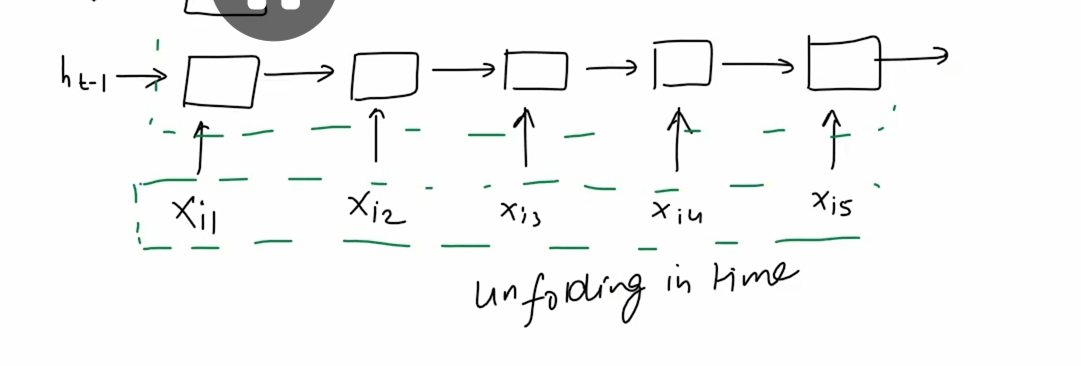
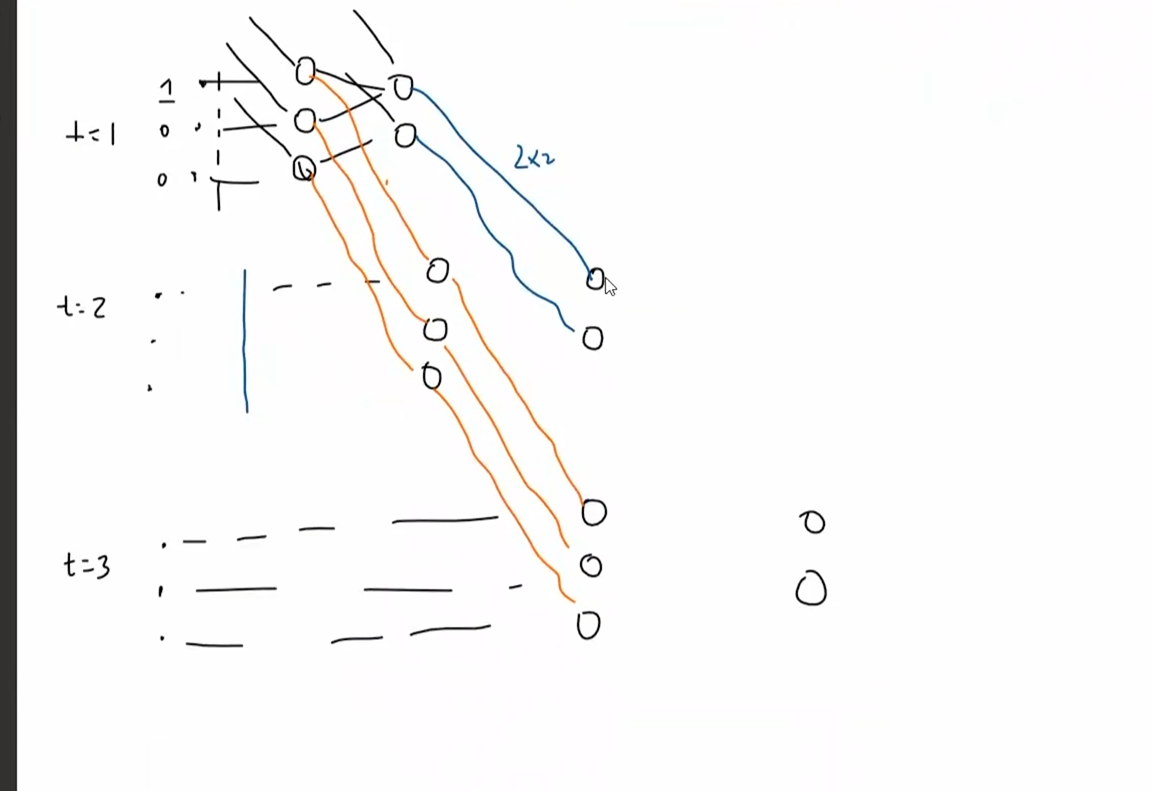

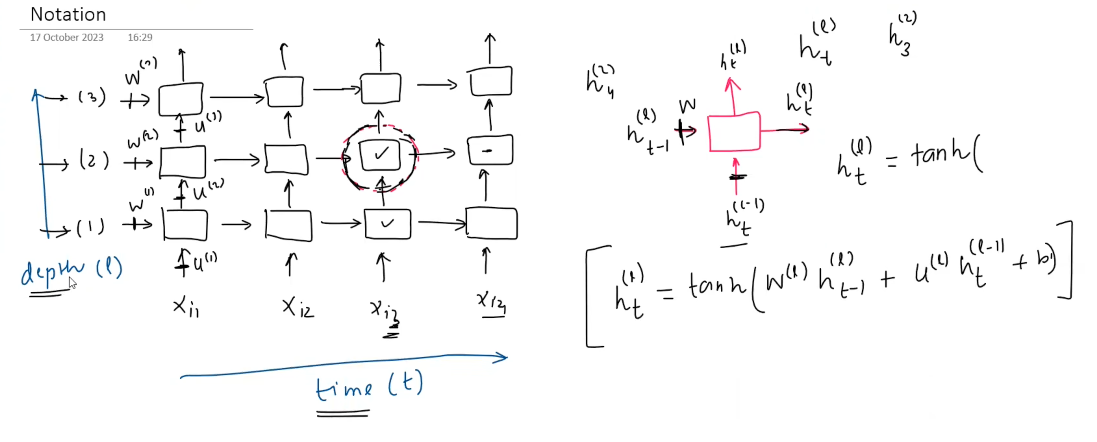

#### The first level will try to do centiment analysis on the word-by-word level and deep level will understand the deep meaning of  the information

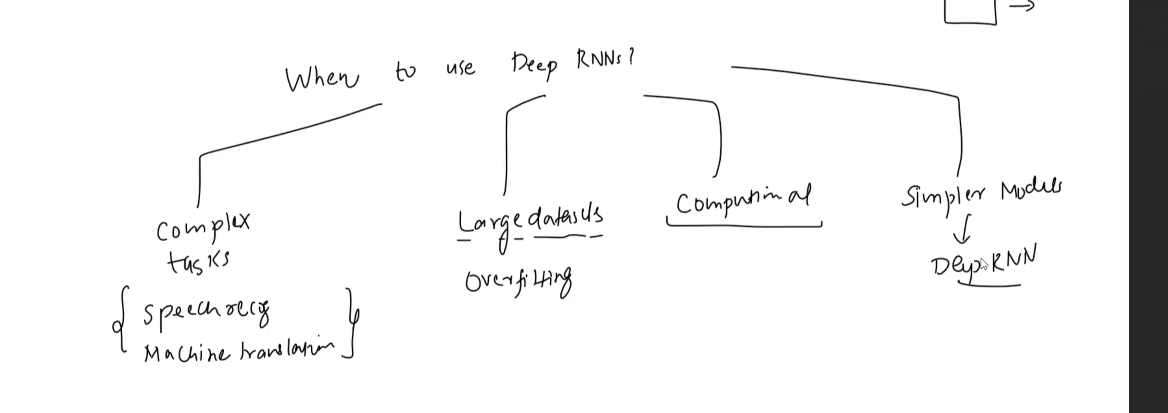

In [45]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import Dense,Embedding,LSTM,SimpleRNN,Input
from tensorflow.keras.models import Sequential


In [28]:
(X_train,y_train),(X_test,y_test) = imdb.load_data(num_words=10000)


In [29]:
X_train.shape


(25000,)

In [30]:
X_test.shape

(25000,)

In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train = pad_sequences(X_train,maxlen=100)
X_test = pad_sequences(X_test,maxlen=100)

In [46]:
model =  Sequential([
    Input(shape=(100,), dtype="int32"),
    Embedding(1000,32,input_length=100),
    SimpleRNN(5,return_sequences=True),
    SimpleRNN(5),
    Dense(1,activation='sigmoid')
])

/mnt/d/DL-Algorithm/lvenv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [47]:
print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [48]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 32)        │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 100, 5)         │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,251 (125.98 KB)

 Trainable params: 32,251 (125.98 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [53]:
history = model.fit(X_train,y_train,epochs=5,batch_size=32,validation_data=(X_test,y_test))

Epoch 1/5


I0000 00:00:1790268663.056588    7531 service.cc:153] XLA service 0x20a512d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790268663.056632    7531 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1790268663.212426    7531 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790268663.640429    7531 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1790268663.751293    7531 dot_merger.cc:481] Merging Dots in computation: sequential_4_1_simple_rnn_7_1_while_body_2421_grad_2650_const_0__.22.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1790268663.755622    7531 dot_merger.cc:481] Merging Dots in computation: sequential_4_1_simple_rnn_6_1_while_body_2310_grad_2871_const_0__.28.clone.clone.clone.clone.clone.clone.clone


  5/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.4938 - loss: 0.7006

I0000 00:00:1790268669.053136    7531 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


780/782 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7387 - loss: 0.5406

I0000 00:00:1790268695.333204    7533 dot_merger.cc:481] Merging Dots in computation: sequential_4_1_simple_rnn_7_1_while_body_2421_grad_2650_const_0__.22.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1790268695.333324    7533 dot_merger.cc:481] Merging Dots in computation: sequential_4_1_simple_rnn_6_1_while_body_2310_grad_2871_const_0__.28.clone.clone.clone.clone.clone.clone.clone


782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.7388 - loss: 0.5405 - val_accuracy: 0.7492 - val_loss: 0.5268
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.7872 - loss: 0.4783 - val_accuracy: 0.7958 - val_loss: 0.4575
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8036 - loss: 0.4468 - val_accuracy: 0.7805 - val_loss: 0.4729
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.8112 - loss: 0.4297 - val_accuracy: 0.7971 - val_loss: 0.4502
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.8016 - loss: 0.4398 - val_accuracy: 0.7734 - val_loss: 0.5018


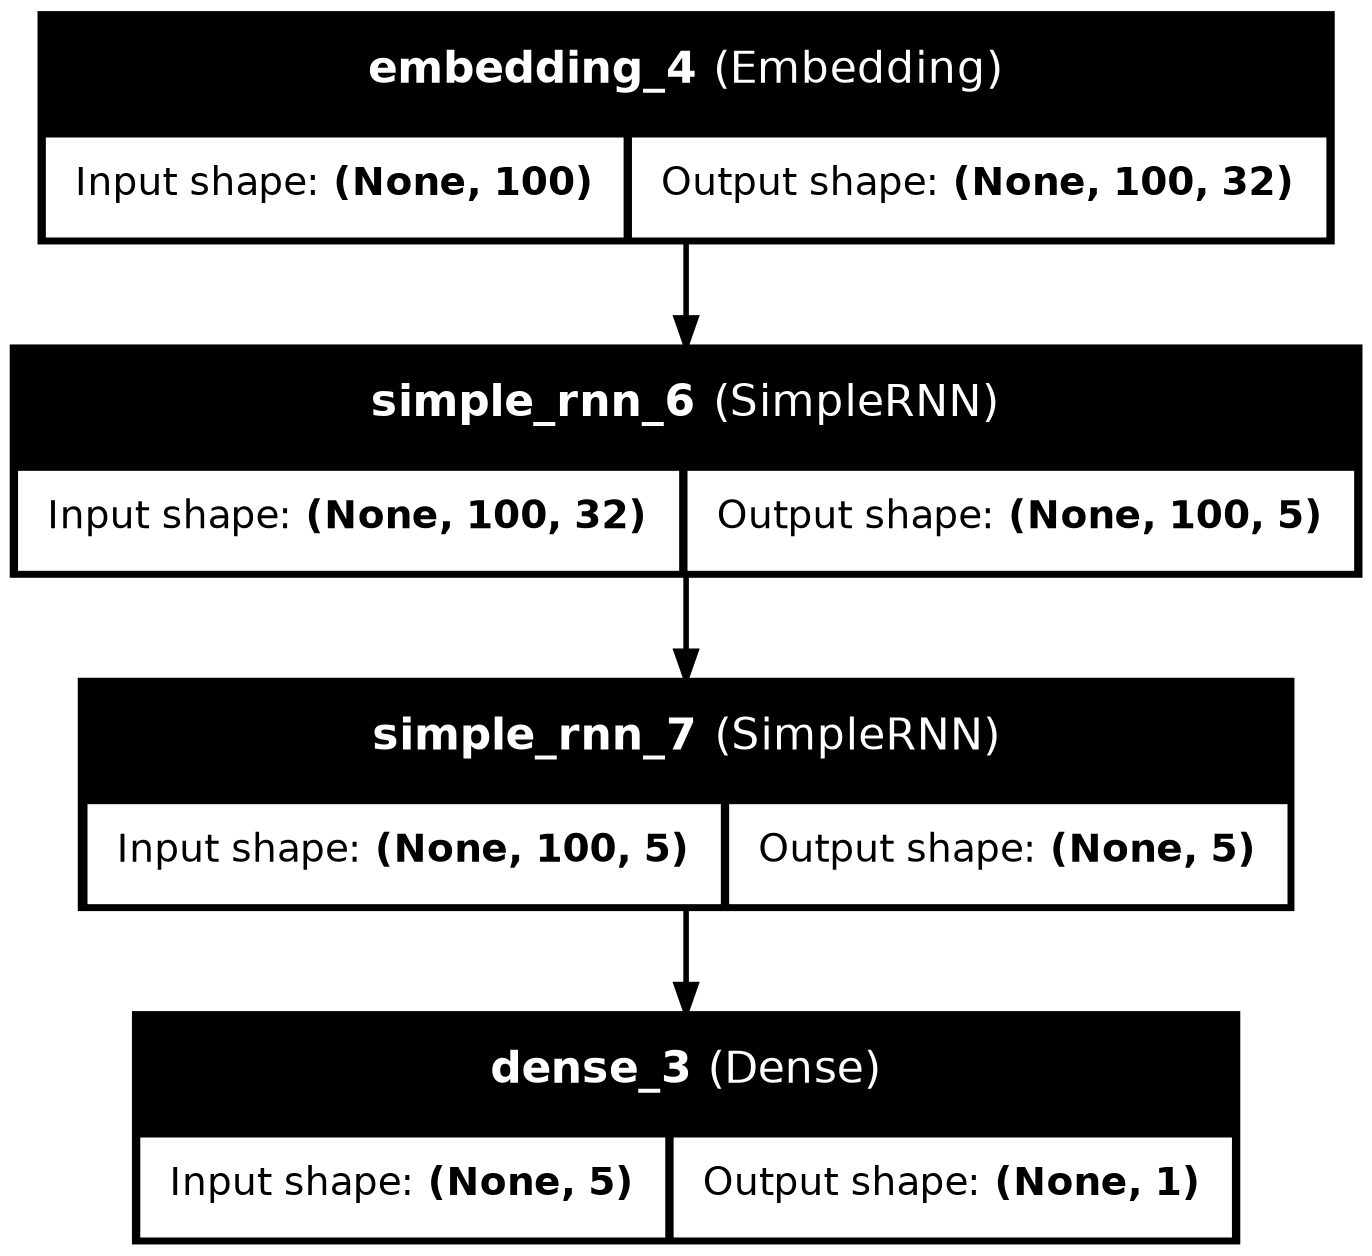

In [54]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="model.png",
    show_shapes=True,
    show_layer_names=True
)

### Disadvantages

- ###### Overfitting